In [2]:
import glob
import tifffile
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats, signal

from skimage.filters import gaussian
import cv2 as cv
import pyclesperanto_prototype as cle
import napari
import random

In [2]:
#get textfile names TRAINING DATA
txtfiles = []
for file in glob.glob("*.tif"):
    txtfiles.append(file)
print(txtfiles)

['cc_DAL_0033.tif', 'cc_DAL_0121.tif', 'cc_DAL_0045.tif', 'cc_DAL_0078.tif', 'cc_DAL_0084.tif', 'cc_DAL_0116.tif', 'cc_DAL_0103.tif', 'cc_DAL_0110.tif', 'cc_DAL_0065.tif', 'cc_DAL_0098.tif', 'cc_DAL_0072.tif', 'cc_DAL_0028.tif']


In [3]:
#get textfile names TEST DATA
txtfiles = []
for file in glob.glob("../dataset_complete/*.tif"):
    txtfiles.append(file[20::])
txtfiles = np.sort(txtfiles)
print(txtfiles)

['cc_DAL_0001.tif' 'cc_DAL_0002.tif' 'cc_DAL_0003.tif' 'cc_DAL_0004.tif'
 'cc_DAL_0005.tif' 'cc_DAL_0006.tif' 'cc_DAL_0007.tif' 'cc_DAL_0008.tif'
 'cc_DAL_0009.tif' 'cc_DAL_0010.tif' 'cc_DAL_0011.tif' 'cc_DAL_0012.tif'
 'cc_DAL_0013.tif' 'cc_DAL_0014.tif' 'cc_DAL_0015.tif' 'cc_DAL_0016.tif'
 'cc_DAL_0017.tif' 'cc_DAL_0018.tif' 'cc_DAL_0019.tif' 'cc_DAL_0020.tif'
 'cc_DAL_0021.tif' 'cc_DAL_0022.tif' 'cc_DAL_0023.tif' 'cc_DAL_0024.tif'
 'cc_DAL_0025.tif' 'cc_DAL_0026.tif' 'cc_DAL_0027.tif' 'cc_DAL_0028.tif'
 'cc_DAL_0029.tif' 'cc_DAL_0030.tif' 'cc_DAL_0031.tif' 'cc_DAL_0032.tif'
 'cc_DAL_0033.tif' 'cc_DAL_0034.tif' 'cc_DAL_0035.tif' 'cc_DAL_0036.tif'
 'cc_DAL_0037.tif' 'cc_DAL_0038.tif' 'cc_DAL_0039.tif' 'cc_DAL_0040.tif'
 'cc_DAL_0041.tif' 'cc_DAL_0042.tif' 'cc_DAL_0043.tif' 'cc_DAL_0044.tif'
 'cc_DAL_0045.tif' 'cc_DAL_0046.tif' 'cc_DAL_0047.tif' 'cc_DAL_0048.tif'
 'cc_DAL_0049.tif' 'cc_DAL_0050.tif' 'cc_DAL_0051.tif' 'cc_DAL_0052.tif'
 'cc_DAL_0053.tif' 'cc_DAL_0054.tif' 'cc_DAL_0055.t

In [3]:
len(txtfiles)

12

In [4]:
# define function to crop window from center of interest
def get_window(a):
    if a < 300:
        a_crop = [0,600]
    elif a > 724:
        a_crop = [424,1024]
    else:
        a_crop = [a - 300, a + 300]
    return a_crop

In [5]:
###
# CONTROL THAT ALTERNATIONS = 0
###
raw_data = 0
img_crop_pre = 0
img_crop = 0
x_min = False
y_min = False 
z_min = False

cc_DAL_0033.tif
[105, 705] [0, 600]


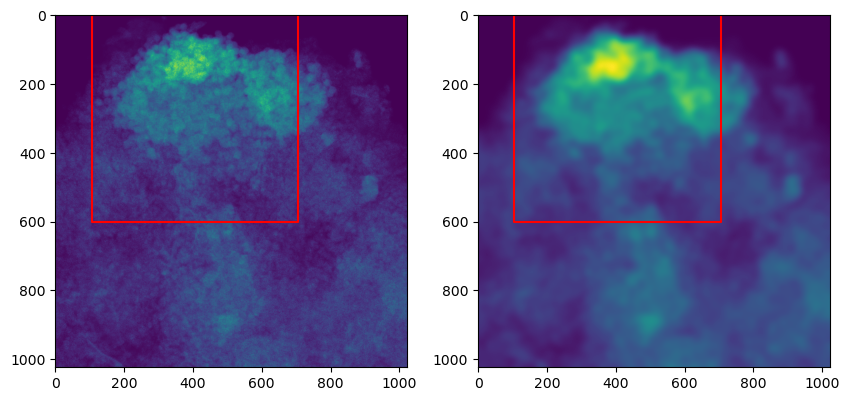

In [6]:
i = 0
raw_data = tifffile.imread('../dataset_complete/'+ str(txtfiles[i]))
print(txtfiles[i])
data_x = np.sum(raw_data[:,0,:,:] * raw_data[:,1,:,:],axis=0)
data_x_gauss = gaussian(data_x,10)

x_max = np.argmax(np.mean(data_x_gauss,axis=0))
y_max = np.argmax(np.mean(data_x_gauss,axis=1))

x_crop = get_window(x_max)
y_crop = get_window(y_max)

#ALTERNATIONS

#x_min = 250
#x_crop = [x_min,x_min + 600]

#y_min = 200
#y_crop = [y_min,y_min + 600]

###

print(x_crop,y_crop)

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(data_x)
plt.plot([x_crop[0],x_crop[0],x_crop[1],x_crop[1],x_crop[0]],[y_crop[0],y_crop[1],y_crop[1],y_crop[0],y_crop[0]],'-r')

plt.subplot(122)
plt.imshow(data_x_gauss)
plt.plot([x_crop[0],x_crop[0],x_crop[1],x_crop[1],x_crop[0]],[y_crop[0],y_crop[1],y_crop[1],y_crop[0],y_crop[0]],'-r')

In [12]:
#find z crop
print(np.shape(raw_data))

#find overlay and show channel 1 of overlay
th = 5
overlay = np.zeros(np.shape(raw_data[:,0,:,:]))
overlay[(raw_data[:,0,:,:] > th) & (raw_data[:,1,:,:] > th)] = 1
data_z = np.sum(np.sum(overlay,axis=-1),axis=-1)

#threshold with 10th percentile
above_th = (data_z > np.percentile(data_z,10)).astype(int)
diff = np.diff(above_th)

if len(np.where(diff[0:np.argmax(data_z)] == 1)[0]) > 0:
    min_z = np.where(diff[0:np.argmax(data_z)] == 1)[0][-1] # find closest above thresholding to max
else:
    min_z = 0

if len(np.where(diff[np.argmax(data_z)::] == -1)[0]) > 0:
    max_z = np.where(diff[np.argmax(data_z)::] == -1)[0][0] + len(diff[0:np.argmax(data_z)]) # find closest below thresholding after max
else:
    max_z = len(data_z)
z_crop = [min_z,max_z] # final z_crop to work with (always check manually in stack)

# ALTERNATIONS
#z_crop[0] = 50
#z_crop[1] = 93

print(z_crop)

(99, 2, 1024, 1024)
[0, 57]


In [13]:
np.max(raw_data)
img_crop_pre = np.copy(raw_data)
for j in range(len(data_z)):
    img_crop_pre[j,:,y_crop[0]:y_crop[1]-1,x_crop[1]-1] = 255
    img_crop_pre[j,:,y_crop[0]:y_crop[1]-1,x_crop[0]] = 255
    img_crop_pre[j,:,y_crop[0],x_crop[0]:x_crop[1]-1] = 255
    img_crop_pre[j,:,y_crop[1]-1,x_crop[0]:x_crop[1]-1] = 255
img_crop_pre[z_crop[0]:z_crop[1],:,50:100,50:100] = 255

viewer = napari.Viewer()
viewer.add_image(cle.pull(img_crop_pre[:,1,:,:]),colormap='green',opacity=0.5)
viewer.add_image(cle.pull(img_crop_pre[:,0,:,:]),colormap='magenta',opacity=0.5)

<Image layer 'Image [1]' at 0x7fa63677f400>

In [1629]:
viewer.close()

In [1630]:
# also delete z slices spotted in napari to not be interesting
img_crop = raw_data[z_crop[0]:z_crop[1],:,y_crop[0]:y_crop[1],x_crop[0]:x_crop[1]]
print(i)

123


In [1631]:
# save all cropped files as tiff and cropping info in dictionary

#for training data:
#tifffile.imwrite(f"cropped/cropped_{txtfiles[i]}", img_crop)

#for test data
tifffile.imwrite(f"../dataset_complete/cropped/cropped_{txtfiles[i]}", img_crop)
dict_crop = {
    "z_crop": z_crop,
    "x_crop": x_crop,
    "y_crop": y_crop
}
#for training data:
np.save(f"cropped/dict_crop_{txtfiles[i][0:-4]}.npy", dict_crop)

#for test data
np.save(f"../dataset_complete/cropped/dict_crop_{txtfiles[i][0:-4]}.npy", dict_crop)

### select slices for training set

In [634]:
# from every cropped file, generate one random z slice and save as single layer tiff (for training data)
random.seed(10)
cropfiles = []
for file in glob.glob("cropped/*.tif"):
    cropfiles.append(file)
cropfiles

for idx,i in enumerate(cropfiles):
    print(i)
    raw_crop = tifffile.imread(str(i))
    z_slice = random.randint(0, np.shape(raw_crop)[0]-1)
    print('z = ', z_slice)
    random_z = raw_crop[z_slice,:,:,:]
    tifffile.imwrite(f"cropped/single_z/{i[8::]}", random_z)
    

cropped/cropped_cc_DAL_0078.tif
z =  36
cropped/cropped_cc_DAL_0045.tif
z =  2
cropped/cropped_cc_DAL_0084.tif
z =  54
cropped/cropped_cc_DAL_0121.tif
z =  61
cropped/cropped_cc_DAL_0033.tif
z =  36
cropped/cropped_cc_DAL_0028.tif
z =  0
cropped/cropped_cc_DAL_0065.tif
z =  13
cropped/cropped_cc_DAL_0110.tif
z =  29
cropped/cropped_cc_DAL_0072.tif
z =  62
cropped/cropped_cc_DAL_0098.tif
z =  52
cropped/cropped_cc_DAL_0103.tif
z =  35
cropped/cropped_cc_DAL_0116.tif
z =  20


In [635]:
a_103 = np.load('cropped/dict_crop_cc_DAL_0084.npy',allow_pickle=True)
a_110 = np.load('cropped/dict_crop_cc_DAL_0116.npy',allow_pickle=True)

In [636]:
a_103

array({'z_crop': [1, 65], 'x_crop': [118, 718], 'y_crop': [0, 600]},
      dtype=object)

In [637]:
a_110

array({'z_crop': [10, 74], 'x_crop': [234, 834], 'y_crop': [0, 600]},
      dtype=object)

## load and inspect previously segmented data stacks

In [3]:
mask_025 = np.load('../../0001segmented_stitch025.npy')
mask_035 = np.load('../../0001segmented_stitch035.npy')
mask_cs = np.load('../../0001segmented_cellstitch.npy')
data = tifffile.imread('../dataset_complete/cropped/cropped_cc_DAL_0001.tif')

In [17]:
viewer = napari.Viewer()
viewer.add_image(cle.pull(data[:,1,:,:]),colormap='green',opacity=0.5)
viewer.add_image(cle.pull(data[:,0,:,:]),colormap='magenta',opacity=0.5)
viewer.add_labels(cle.pull(mask_025))
#viewer.add_labels(cle.pull(mask_035))
#viewer.add_labels(cle.pull(mask_cs))

<Labels layer 'mask_025' at 0x7fa608783eb0>